# GridCast Europe – Datenimport, Zusammenführung und explorative Analyse

**QUA³CK-Phase:** U – *Understanding the Data*  
**Beobachtungseinheit:** Land × UTC-Stunde  
**Kernländer:** Deutschland (`DE`), Frankreich (`FR`), Polen (`PL`)  
**Modellfenster:** 2015–2019

Dieses Notebook lädt die beiden unveränderten OPSD-Rohdatensätze,
prüft ihre Zeitachsen, überführt sie in ein gemeinsames Long-Format,
verknüpft Last und Wetter, erzeugt Kalender- und Wetterfeatures und
untersucht Datenqualität sowie zentrale Muster.

Die Zielvariable ist die tatsächliche nationale Stromlast in MW. Die
Wetterwerte stammen aus MERRA-2-Reanalysedaten und sind im historischen
Backtest beobachtete Eingaben – keine Wetterprognosen.

## Scope-Entscheidung und Erweiterbarkeit

Drei Länder sind eine bewusste Qualitätsentscheidung, keine technische
Begrenzung. Zusätzliche Länder können über die zentrale
`COUNTRY_REGISTRY` ergänzt werden; Import, Umformung, Join und Feature
Engineering arbeiten dann unverändert weiter.

Vor einer Freigabe müssen pro Land dennoch nationale Lastdefinition,
Wetter-Join, Missingness, Ausreißer, Zeitzone, Feiertage und Modellfehler
geprüft werden. Der Aufwand wächst deshalb bei Berechnung und Code
annähernd linear, bei Qualitätssicherung und Interpretation jedoch
teilweise überlinear. Eine Europa-Karte in Streamlit kann später
unabhängig davon alle **bereits freigegebenen** Länder darstellen.

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")

cwd = Path.cwd().resolve()
if (cwd / "src").is_dir() and (cwd / "data").is_dir():
    PROJECT_ROOT = cwd
elif (cwd.parent / "src").is_dir() and (cwd.parent / "data").is_dir():
    PROJECT_ROOT = cwd.parent
else:
    raise RuntimeError(
        "Projektwurzel nicht gefunden. Notebook aus dem Repository "
        "oder dem Ordner notebooks/ starten."
    )

SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from gridcast import (
    build_climatology,
    build_model_table,
    load_opsd_sources,
    quality_by_country,
    resolve_input_paths,
    select_country_specs,
    validate_hourly_axis,
)

RANDOM_STATE = 42
COUNTRY_CODES = ("DE", "FR", "PL")
SPECS = select_country_specs(COUNTRY_CODES)

print("Projektwurzel:", PROJECT_ROOT)
print("Kernländer:", ", ".join(COUNTRY_CODES))

Projektwurzel: /workspace/scratch/b16d81756317/gridcast_work
Kernländer: DE, FR, PL


## 1. Datenquellen und reproduzierbarer Zugriff

Verwendet werden:

1. **OPSD Time Series**, Version `2020-10-06`  
   DOI: https://doi.org/10.25832/time_series/2020-10-06
2. **OPSD Weather Data**, Version `2020-09-16`  
   DOI: https://doi.org/10.25832/weather_data/2020-09-16

Die großen Rohdateien werden nicht in Git versioniert. Das Skript
`scripts/download_opsd_data.py` stellt den Download reproduzierbar her.
Alternativ können die Pfade über `GRIDCAST_LOAD_CSV` und
`GRIDCAST_WEATHER_CSV` gesetzt werden.

In [2]:
country_config = pd.DataFrame(
    [
        {
            "country": spec.code,
            "name": spec.name,
            "timezone": spec.timezone,
            "load_column": spec.load_column,
            "weather_columns": ", ".join(spec.weather_columns),
        }
        for spec in SPECS.values()
    ]
)
display(country_config)

load_path, weather_path = resolve_input_paths(PROJECT_ROOT)
def project_relative_or_absolute(path: Path) -> str:
    try:
        return str(path.relative_to(PROJECT_ROOT))
    except ValueError:
        return str(path)

source_files = pd.DataFrame(
    [
        {
            "dataset": "OPSD Time Series",
            "path": project_relative_or_absolute(load_path),
            "size_mb": load_path.stat().st_size / 1024**2,
        },
        {
            "dataset": "OPSD Weather Data",
            "path": project_relative_or_absolute(weather_path),
            "size_mb": weather_path.stat().st_size / 1024**2,
        },
    ]
)
display(source_files.round({"size_mb": 1}))

,country,name,timezone,load_column,weather_columns
0,DE,Deutschland,Europe/Berlin,DE_load_actual_entsoe_transparency,"DE_temperature, DE_radiation_direct_horizontal, DE_radiation_diffuse_horizontal"
1,FR,Frankreich,Europe/Paris,FR_load_actual_entsoe_transparency,"FR_temperature, FR_radiation_direct_horizontal, FR_radiation_diffuse_horizontal"
2,PL,Polen,Europe/Warsaw,PL_load_actual_entsoe_transparency,"PL_temperature, PL_radiation_direct_horizontal, PL_radiation_diffuse_horizontal"


,dataset,path,size_mb
0,OPSD Time Series,/workspace/scratch/b16d81756317/project_sources/12-time_series_60min_singleindex-3-.csv,124.3
1,OPSD Weather Data,/tmp/gridcast-weather/weather_data.csv,222.7


## 2. Selektiver Import und Schema

Obwohl die Rohdateien 300 beziehungsweise 85 Spalten besitzen, werden
nur Zeitstempel und die explizit freigegebenen Länderreihen eingelesen.
Das reduziert Speicherbedarf und verhindert, dass Regelzonen,
Gebotszonen, Forecasts oder interpolierte Varianten versehentlich in
das Zielmodell gelangen.

In [3]:
load_raw, weather_raw = load_opsd_sources(
    load_path, weather_path, SPECS
)

schema_summary = pd.DataFrame(
    [
        {
            "dataset": "Last (selektiv)",
            "rows": len(load_raw),
            "columns": load_raw.shape[1],
            "memory_mb": load_raw.memory_usage(deep=True).sum() / 1024**2,
        },
        {
            "dataset": "Wetter (selektiv)",
            "rows": len(weather_raw),
            "columns": weather_raw.shape[1],
            "memory_mb": weather_raw.memory_usage(deep=True).sum() / 1024**2,
        },
    ]
)
display(schema_summary.round({"memory_mb": 1}))
display(load_raw.head(3))
display(weather_raw.head(3))

,dataset,rows,columns,memory_mb
0,Last (selektiv),50401,4,1.5
1,Wetter (selektiv),350640,10,26.8


,utc_timestamp,DE_load_actual_entsoe_transparency,FR_load_actual_entsoe_transparency,PL_load_actual_entsoe_transparency
0,2014-12-31 23:00:00+00:00,NaN,NaN,NaN
1,2015-01-01 00:00:00+00:00,41151.0,NaN,NaN
2,2015-01-01 01:00:00+00:00,40135.0,69773.0,13979.46


,utc_timestamp,DE_temperature,DE_radiation_direct_horizontal,DE_radiation_diffuse_horizontal,FR_temperature,FR_radiation_direct_horizontal,FR_radiation_diffuse_horizontal,PL_temperature,PL_radiation_direct_horizontal,PL_radiation_diffuse_horizontal
0,1980-01-01 00:00:00+00:00,-1.261,0.0,0.0,-0.537,0.0,0.0,-3.721,0.0,0.0
1,1980-01-01 01:00:00+00:00,-1.414,0.0,0.0,-0.489,0.0,0.0,-3.806,0.0,0.0
2,1980-01-01 02:00:00+00:00,-1.571,0.0,0.0,-0.391,0.0,0.0,-3.868,0.0,0.0


## 3. Qualitätsprüfung der Zeitachsen

Für beide Quellen werden doppelte Zeitstempel, Sortierung und fehlende
UTC-Stunden zwischen erstem und letztem Zeitstempel geprüft. Die Prüfung
betrifft zunächst die **Indexachse**; fehlende Messwerte innerhalb
vorhandener Zeilen werden anschließend separat analysiert.

In [4]:
axis_quality = pd.DataFrame(
    [
        validate_hourly_axis(load_raw, "OPSD Last"),
        validate_hourly_axis(weather_raw, "OPSD Wetter"),
    ]
)
display(axis_quality)

assert axis_quality["duplicate_timestamps"].eq(0).all()
assert axis_quality["missing_index_hours"].eq(0).all()
assert axis_quality["monotonic_increasing"].all()

,dataset,rows,start_utc,end_utc,duplicate_timestamps,missing_index_hours,monotonic_increasing
0,OPSD Last,50401,2014-12-31 23:00:00+00:00,2020-09-30 23:00:00+00:00,0,0,True
1,OPSD Wetter,350640,1980-01-01 00:00:00+00:00,2019-12-31 23:00:00+00:00,0,0,True


## 4. Long-Format, 1:1-Join und Features

Die nationalen Spalten werden auf die Beobachtungseinheit
`country × utc_timestamp` gebracht. Der Join wird mit
`validate="one_to_one"` abgesichert.

Kalendermerkmale werden aus der länderspezifischen **Lokalzeit**
abgeleitet; der eindeutige technische Schlüssel bleibt UTC. Damit werden
Sommerzeitwechsel korrekt behandelt, ohne doppelte UTC-Zeitstempel zu
erzeugen.

Erzeugte Features:

- lokale Stunde, Wochentag, Monat, Jahreszeit, Wochenende
- zyklische Sinus-/Kosinus-Kodierungen
- Temperatur, Temperaturquadrat
- Heating Degrees unter 15 °C und Cooling Degrees über 22 °C
- direkte und diffuse horizontale Strahlung

In [5]:
model_full, model_data = build_model_table(
    load_raw, weather_raw, SPECS
)

print("Vor Entfernen fehlender Zielwerte:", model_full.shape)
print("Nach Entfernen fehlender Zielwerte:", model_data.shape)
print("Eindeutige Schlüssel:",
      not model_full.duplicated(["country", "utc_timestamp"]).any())
display(model_data.head(3))

,utc_timestamp,country,load_mw,temperature_c,radiation_direct_wm2,radiation_diffuse_wm2,local_date,local_hour,local_weekday,local_month,local_day_of_year,utc_offset_hours,is_weekend,season,hour_sin,hour_cos,weekday_sin,weekday_cos,year_sin,year_cos,temperature_sq,heating_degrees,cooling_degrees,split
0,2015-01-01 00:00:00+00:00,DE,41151.0,-0.981,0.0,0.0,2015-01-01,1,3,1,1,1,0,Winter,0.258819,0.965926,0.433884,-0.900969,0.0,1.0,0.962361,15.981,0.0,train
1,2015-01-01 01:00:00+00:00,DE,40135.0,-1.035,0.0,0.0,2015-01-01,2,3,1,1,1,0,Winter,0.500000,0.866025,0.433884,-0.900969,0.0,1.0,1.071225,16.035,0.0,train
2,2015-01-01 01:00:00+00:00,FR,69773.0,-1.768,0.0,0.0,2015-01-01,2,3,1,1,1,0,Winter,0.500000,0.866025,0.433884,-0.900969,0.0,1.0,3.125824,16.768,0.0,train


Vor Entfernen fehlender Zielwerte: (131472, 24)
Nach Entfernen fehlender Zielwerte: (131441, 24)
Eindeutige Schlüssel: True


## 5. Missingness und Bereinigungsentscheidung

Fehlende Wetterfeatures könnten später mit einer ausschließlich auf
Trainingsdaten angepassten Strategie behandelt werden. Im gemeinsamen
Fenster 2015–2019 sind sie jedoch vollständig.

Die 31 fehlenden Lastwerte betreffen die **Zielvariable**. Sie werden
entfernt statt imputiert: Eine erfundene Zielvariable würde die spätere
Gütemessung künstlich beeinflussen. Es gehen nur rund 0,024 % der
möglichen Länder-Stunden verloren.

In [6]:
quality = quality_by_country(model_full)
display(
    quality[
        [
            "country",
            "expected_hours",
            "missing_load",
            "missing_temperature",
            "missing_direct_radiation",
            "missing_diffuse_radiation",
            "complete_load_hours",
            "load_completeness_pct",
            "min_load_mw",
            "median_load_mw",
            "max_load_mw",
        ]
    ].round(3)
)

missing_target = model_full.loc[
    model_full["load_mw"].isna(), ["country", "utc_timestamp"]
]
display(missing_target)

total_missing_pct = 100 * len(missing_target) / len(model_full)
print(f"Entfernte Zielzeilen: {len(missing_target):,}")
print(f"Anteil: {total_missing_pct:.4f} %")

,country,expected_hours,missing_load,missing_temperature,missing_direct_radiation,missing_diffuse_radiation,complete_load_hours,load_completeness_pct,min_load_mw,median_load_mw,max_load_mw
0,DE,43824,0,0,0,0,43824,100.000,31307.00,55467.00,77549.00
1,FR,43824,30,0,0,0,43794,99.932,30426.00,52276.50,94492.00
2,PL,43824,1,0,0,0,43823,99.998,11199.51,19228.08,26297.15


,country,utc_timestamp
1,FR,2015-01-01 00:00:00+00:00
2,PL,2015-01-01 00:00:00+00:00
55210,FR,2017-02-05 19:00:00+00:00
55213,FR,2017-02-05 20:00:00+00:00
55216,FR,2017-02-05 21:00:00+00:00
55219,FR,2017-02-05 22:00:00+00:00
55222,FR,2017-02-05 23:00:00+00:00
55225,FR,2017-02-06 00:00:00+00:00
55228,FR,2017-02-06 01:00:00+00:00
55231,FR,2017-02-06 02:00:00+00:00


Entfernte Zielzeilen: 31
Anteil: 0.0236 %


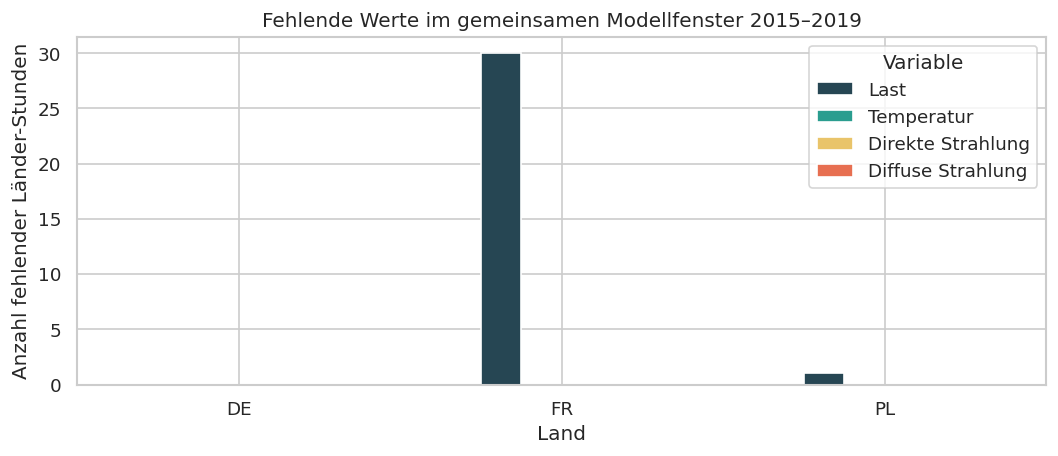

In [7]:
missing_plot = quality.set_index("country")[
    [
        "missing_load",
        "missing_temperature",
        "missing_direct_radiation",
        "missing_diffuse_radiation",
    ]
].rename(
    columns={
        "missing_load": "Last",
        "missing_temperature": "Temperatur",
        "missing_direct_radiation": "Direkte Strahlung",
        "missing_diffuse_radiation": "Diffuse Strahlung",
    }
)

ax = missing_plot.plot(
    kind="bar", figsize=(9, 4), color=["#264653", "#2a9d8f", "#e9c46a", "#e76f51"]
)
ax.set_title("Fehlende Werte im gemeinsamen Modellfenster 2015–2019")
ax.set_xlabel("Land")
ax.set_ylabel("Anzahl fehlender Länder-Stunden")
ax.legend(title="Variable")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Chronologischer Split

- **Training:** 2015–2017
- **Validierung:** 2018
- **Test:** 2019

Der Split erfolgt nach Zeit und nicht zufällig. So simuliert der Test
einen vollständig späteren, beim Training unbekannten Zeitraum.
Preprocessing-Parameter, Baselines und Modelle dürfen später nur auf dem
Trainingsblock angepasst werden.

In [8]:
split_counts = (
    model_data.groupby(["country", "split"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["train", "validation", "test"])
)
split_counts["total"] = split_counts.sum(axis=1)
display(split_counts)

assert set(model_data["split"]) == {"train", "validation", "test"}
assert model_data.loc[model_data["split"].eq("train"), "utc_timestamp"].max().year == 2017
assert model_data.loc[model_data["split"].eq("validation"), "utc_timestamp"].min().year == 2018
assert model_data.loc[model_data["split"].eq("test"), "utc_timestamp"].min().year == 2019

split,train,validation,test,total
country,,,,
DE,26304,8760,8760,43824
FR,26290,8749,8755,43794
PL,26303,8760,8760,43823


## 7. Explorative Analyse der Lastverteilungen

Histogramme und Boxplots zeigen Größenordnung, Streuung, Schiefe und
potenzielle Extremwerte. Länder werden nicht anhand ihrer absoluten MW
direkt verglichen, ohne ihre unterschiedliche Systemgröße zu beachten.

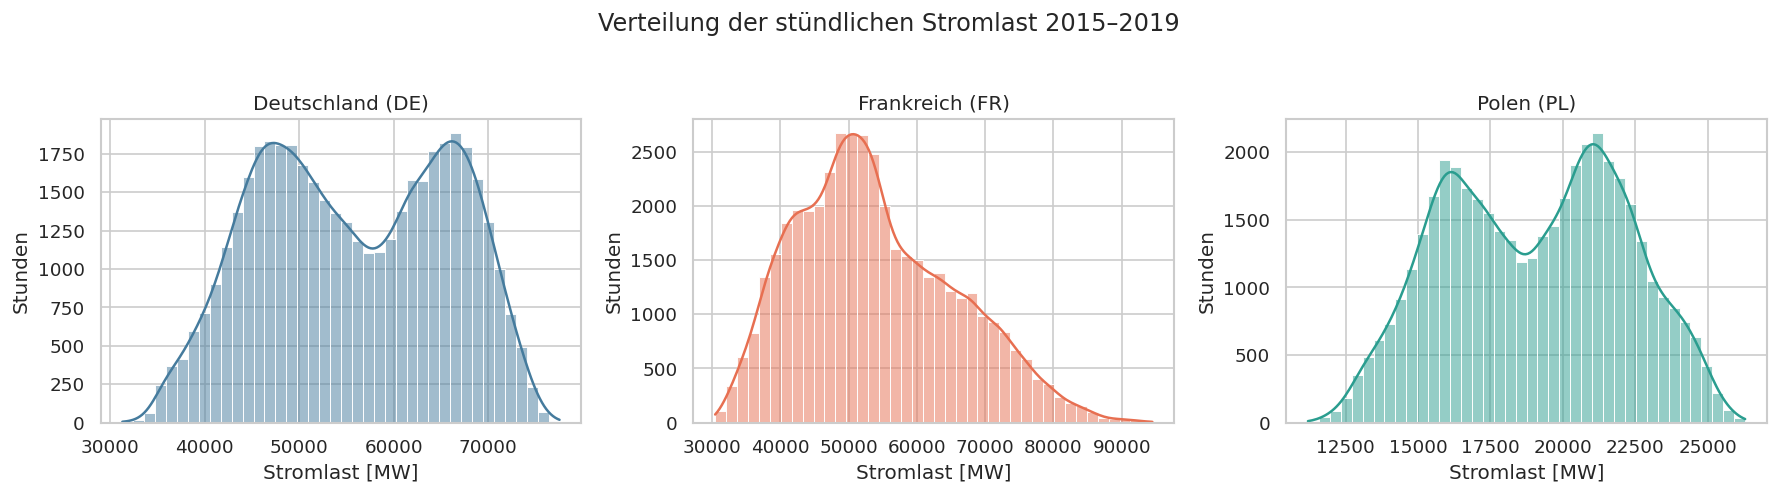

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
colors = {"DE": "#457b9d", "FR": "#e76f51", "PL": "#2a9d8f"}
for ax, code_value in zip(axes, COUNTRY_CODES):
    subset = model_data.loc[model_data["country"].eq(code_value), "load_mw"]
    sns.histplot(subset, bins=40, kde=True, ax=ax, color=colors[code_value])
    ax.set_title(f"{SPECS[code_value].name} ({code_value})")
    ax.set_xlabel("Stromlast [MW]")
    ax.set_ylabel("Stunden")
fig.suptitle("Verteilung der stündlichen Stromlast 2015–2019", y=1.03)
plt.tight_layout()
plt.show()

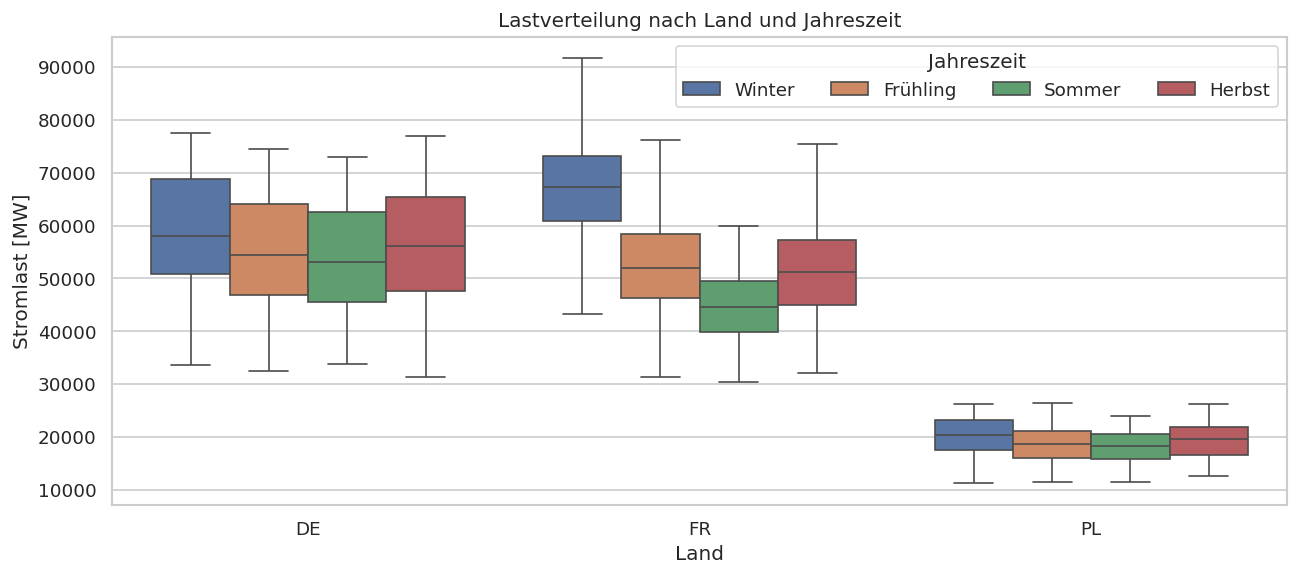

In [10]:
plt.figure(figsize=(11, 5))
sns.boxplot(
    data=model_data,
    x="country",
    y="load_mw",
    hue="season",
    hue_order=["Winter", "Frühling", "Sommer", "Herbst"],
    showfliers=False,
)
plt.title("Lastverteilung nach Land und Jahreszeit")
plt.xlabel("Land")
plt.ylabel("Stromlast [MW]")
plt.legend(title="Jahreszeit", ncol=4)
plt.tight_layout()
plt.show()

## 8. Ausreißer-Screening

Die IQR-Regel markiert statistisch ungewöhnliche Werte, beweist aber
keinen Messfehler. Gerade winterliche Spitzen in Frankreich können
reale, temperatursensitive Lastzustände sein. Deshalb werden plausible
Extremwerte **nicht automatisch entfernt**; negative oder physikalisch
unmögliche Werte wären separat zu behandeln.

In [11]:
outlier_rows = []
for code_value, group in model_data.groupby("country", observed=True):
    q1, q3 = group["load_mw"].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    flagged = group["load_mw"].lt(lower) | group["load_mw"].gt(upper)
    outlier_rows.append(
        {
            "country": code_value,
            "q1_mw": q1,
            "q3_mw": q3,
            "iqr_lower_mw": lower,
            "iqr_upper_mw": upper,
            "iqr_flags": int(flagged.sum()),
            "negative_or_zero_load": int(group["load_mw"].le(0).sum()),
        }
    )
outlier_screening = pd.DataFrame(outlier_rows)
display(outlier_screening.round(2))

,country,q1_mw,q3_mw,iqr_lower_mw,iqr_upper_mw,iqr_flags,negative_or_zero_load
0,DE,47432.00,64788.25,21397.62,90822.62,0,0
1,FR,45178.50,61906.50,20086.50,86998.50,116,0
2,PL,16380.72,21521.83,8669.06,29233.50,0,0


## 9. Tages-, Wochen- und Saisonmuster

Diese Profile begründen die Kalenderfeatures und die spätere
Kalender-Baseline. Für die Baseline selbst dürfen Gruppenmittelwerte
später ausschließlich aus dem Trainingszeitraum stammen.

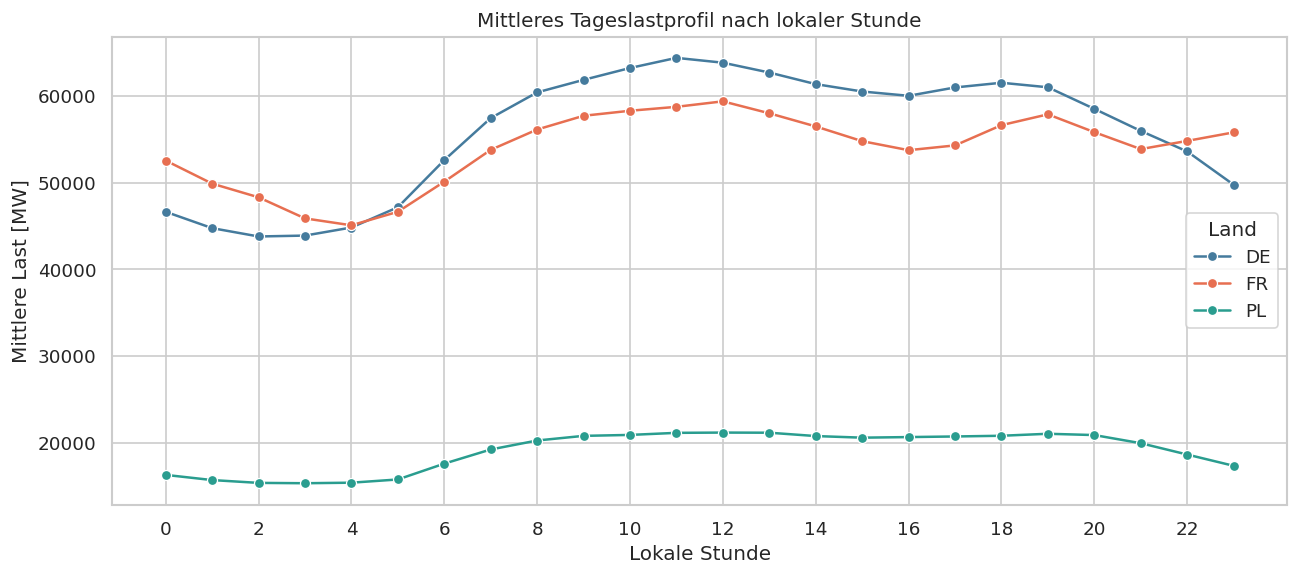

In [12]:
hourly_profile = (
    model_data.groupby(["country", "local_hour"], observed=True)["load_mw"]
    .mean()
    .reset_index()
)
plt.figure(figsize=(11, 5))
sns.lineplot(
    data=hourly_profile,
    x="local_hour",
    y="load_mw",
    hue="country",
    marker="o",
    palette=colors,
)
plt.title("Mittleres Tageslastprofil nach lokaler Stunde")
plt.xlabel("Lokale Stunde")
plt.ylabel("Mittlere Last [MW]")
plt.xticks(range(0, 24, 2))
plt.legend(title="Land")
plt.tight_layout()
plt.show()

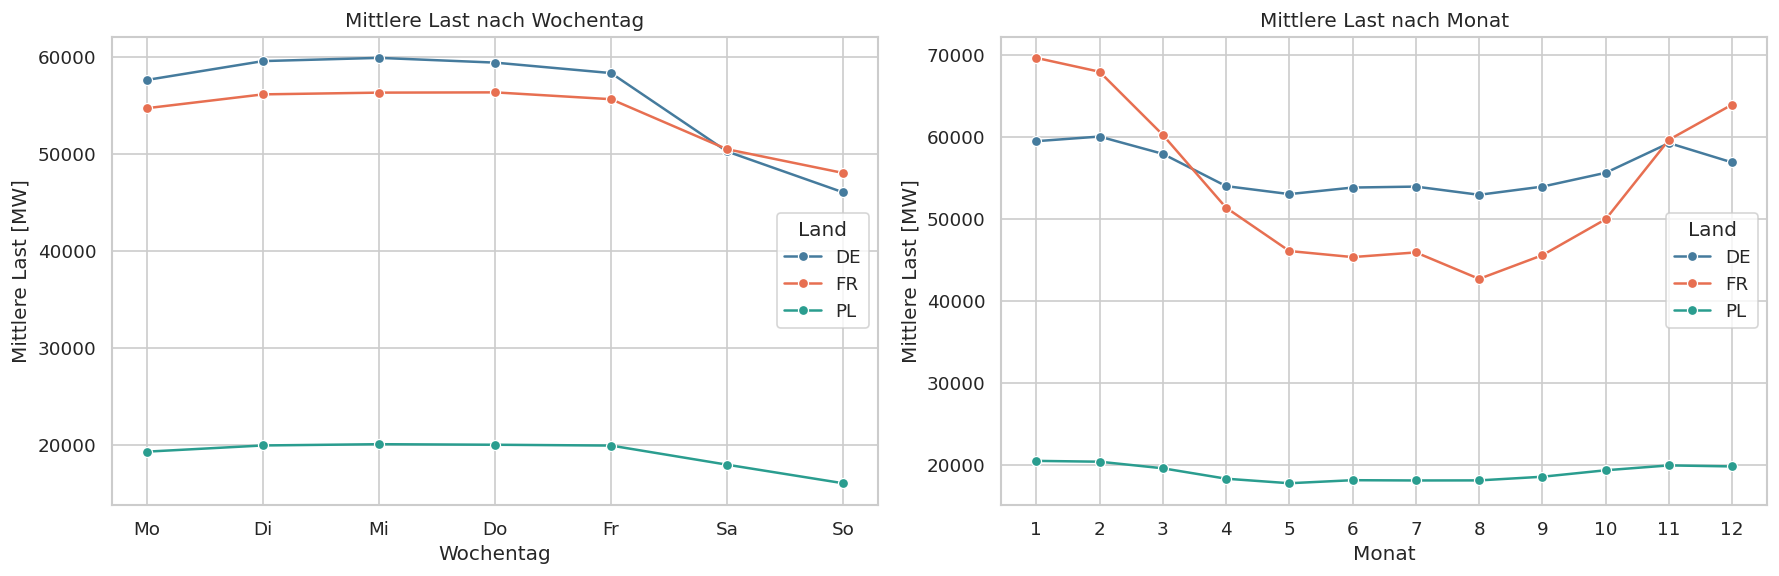

In [13]:
weekday_names = {
    0: "Mo", 1: "Di", 2: "Mi", 3: "Do", 4: "Fr", 5: "Sa", 6: "So"
}
weekday_profile = (
    model_data.groupby(["country", "local_weekday"], observed=True)["load_mw"]
    .mean()
    .reset_index()
)
weekday_profile["weekday"] = weekday_profile["local_weekday"].map(weekday_names)

monthly_profile = (
    model_data.groupby(["country", "local_month"], observed=True)["load_mw"]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(
    data=weekday_profile,
    x="local_weekday",
    y="load_mw",
    hue="country",
    marker="o",
    palette=colors,
    ax=axes[0],
)
axes[0].set_title("Mittlere Last nach Wochentag")
axes[0].set_xlabel("Wochentag")
axes[0].set_ylabel("Mittlere Last [MW]")
axes[0].set_xticks(range(7), [weekday_names[i] for i in range(7)])
axes[0].legend(title="Land")

sns.lineplot(
    data=monthly_profile,
    x="local_month",
    y="load_mw",
    hue="country",
    marker="o",
    palette=colors,
    ax=axes[1],
)
axes[1].set_title("Mittlere Last nach Monat")
axes[1].set_xlabel("Monat")
axes[1].set_ylabel("Mittlere Last [MW]")
axes[1].set_xticks(range(1, 13))
axes[1].legend(title="Land")
plt.tight_layout()
plt.show()

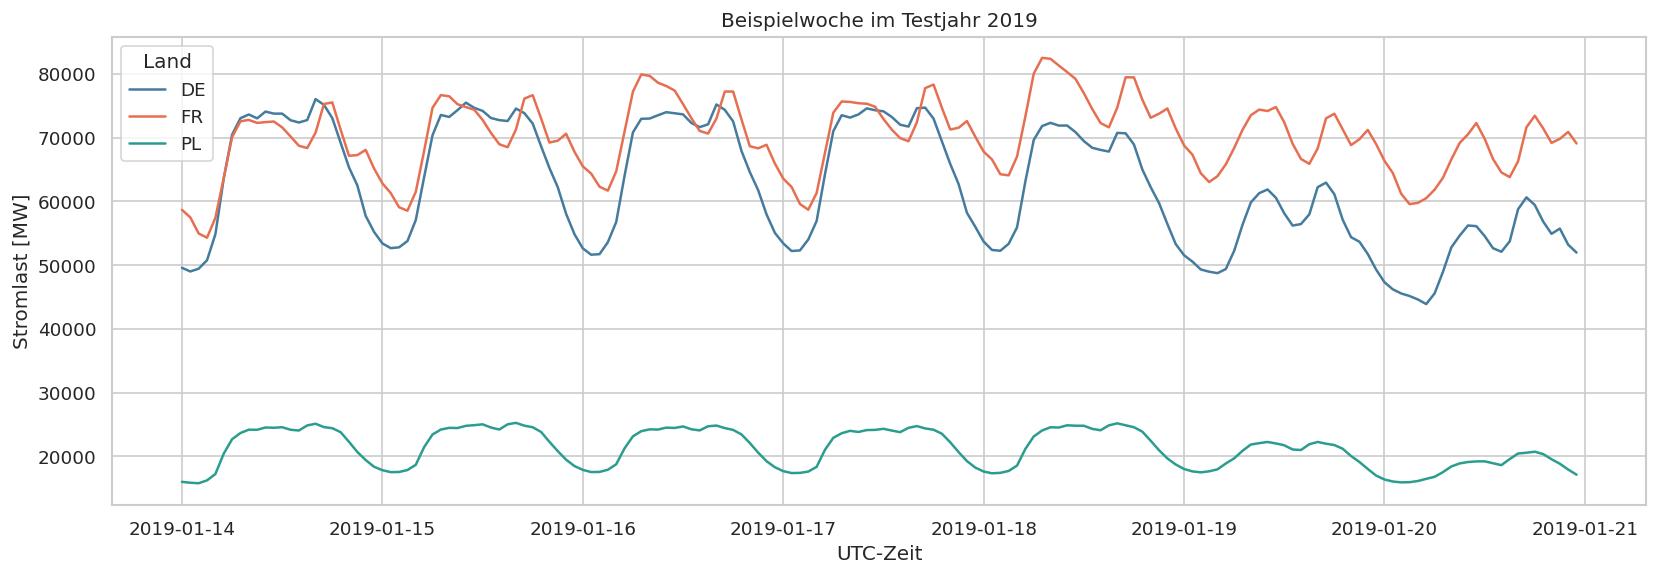

In [14]:
example_start = pd.Timestamp("2019-01-14T00:00:00Z")
example_end = example_start + pd.Timedelta(days=7)
example_week = model_data.loc[
    model_data["utc_timestamp"].between(
        example_start, example_end, inclusive="left"
    )
]
plt.figure(figsize=(14, 5))
sns.lineplot(
    data=example_week,
    x="utc_timestamp",
    y="load_mw",
    hue="country",
    palette=colors,
)
plt.title("Beispielwoche im Testjahr 2019")
plt.xlabel("UTC-Zeit")
plt.ylabel("Stromlast [MW]")
plt.legend(title="Land")
plt.tight_layout()
plt.show()

## 10. Wetter-Last-Zusammenhänge

Ein einfacher Pearson-Koeffizient bildet nichtlineare Beziehungen nur
unvollständig ab. Scatterplots und die abgeleiteten Heiz-/Kühlgrad-
Merkmale helfen, U- oder J-förmige Zusammenhänge sichtbar zu machen.
Für lesbare Grafiken wird reproduzierbar eine Stichprobe gezogen; das
Modelltraining verwendet später alle bereinigten Zeilen.

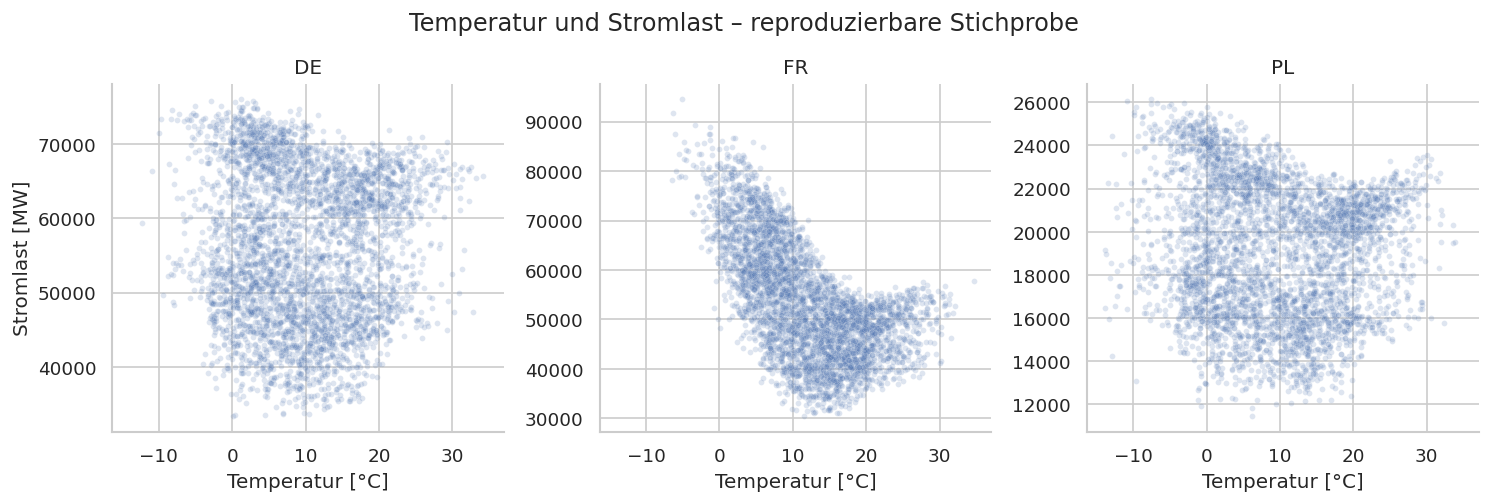

In [15]:
sample = (
    model_data.groupby("country", group_keys=False, observed=True)
    .sample(n=4_000, random_state=RANDOM_STATE)
)

grid = sns.FacetGrid(
    sample,
    col="country",
    col_order=list(COUNTRY_CODES),
    height=4,
    aspect=1.05,
    sharex=True,
    sharey=False,
)
grid.map_dataframe(
    sns.scatterplot,
    x="temperature_c",
    y="load_mw",
    alpha=0.18,
    s=12,
)
grid.set_axis_labels("Temperatur [°C]", "Stromlast [MW]")
grid.set_titles("{col_name}")
grid.figure.suptitle(
    "Temperatur und Stromlast – reproduzierbare Stichprobe", y=1.05
)
plt.show()

,,load_mw,temperature_c,radiation_direct_wm2,radiation_diffuse_wm2
country,,,,,
DE,load_mw,1.0,-0.027,0.256,0.374
FR,load_mw,1.0,-0.620,-0.096,0.005
PL,load_mw,1.0,-0.105,0.178,0.278


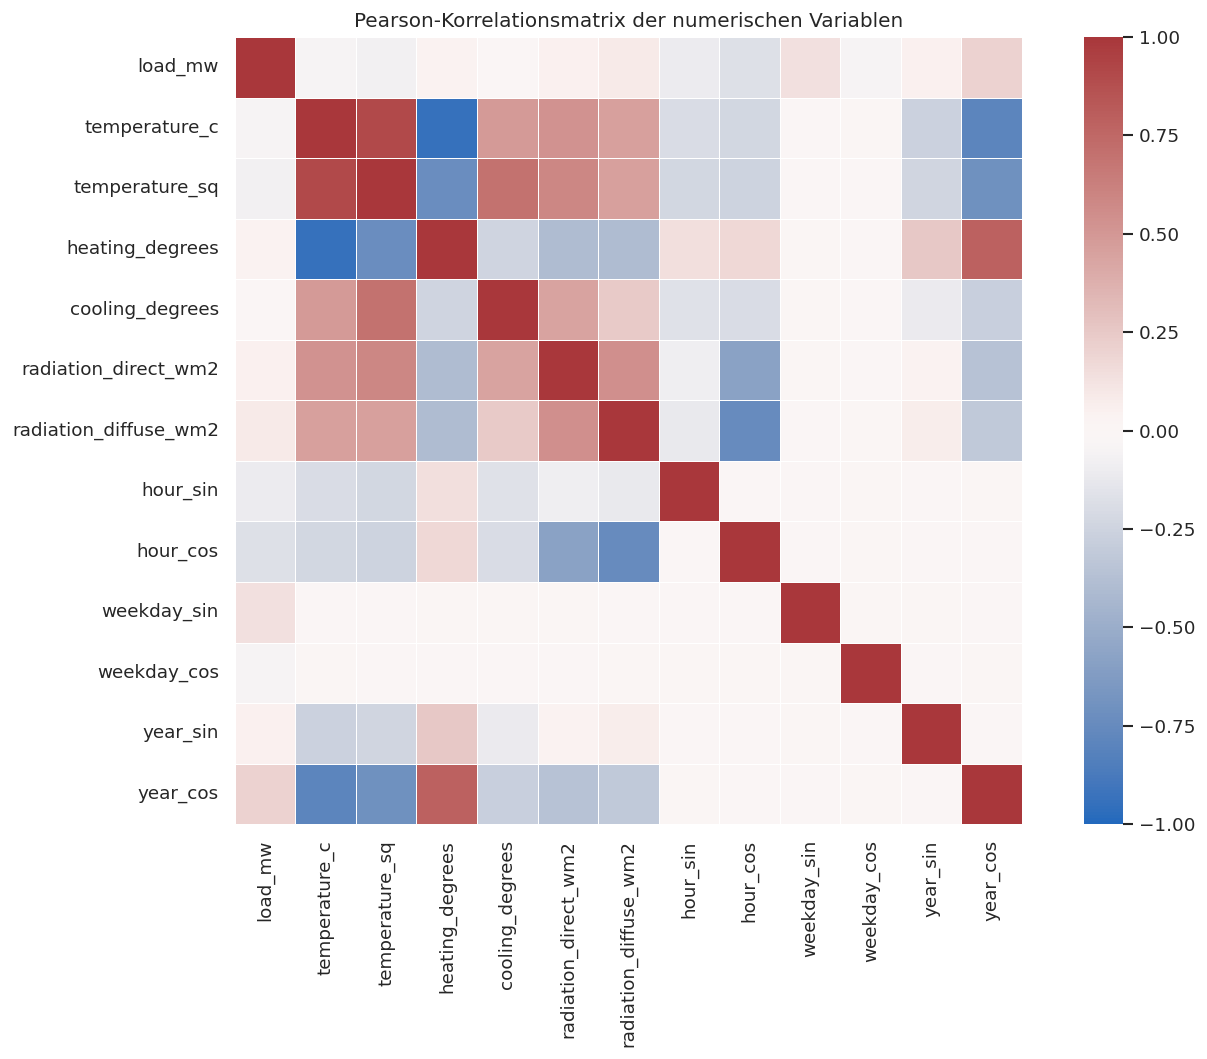

In [16]:
correlation_columns = [
    "load_mw",
    "temperature_c",
    "temperature_sq",
    "heating_degrees",
    "cooling_degrees",
    "radiation_direct_wm2",
    "radiation_diffuse_wm2",
    "hour_sin",
    "hour_cos",
    "weekday_sin",
    "weekday_cos",
    "year_sin",
    "year_cos",
]
correlation = model_data[correlation_columns].corr(method="pearson")

plt.figure(figsize=(12, 9))
sns.heatmap(
    correlation,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.3,
)
plt.title("Pearson-Korrelationsmatrix der numerischen Variablen")
plt.tight_layout()
plt.show()

display(
    model_data.groupby("country", observed=True)[
        ["load_mw", "temperature_c", "radiation_direct_wm2",
         "radiation_diffuse_wm2"]
    ].corr().loc[(slice(None), "load_mw"), :].round(3)
)

## 11. Historischer Zeittrend – nur explorativ

Jahresmittel können kurzfristige Bewegungen beschreiben, rechtfertigen
aber keine automatische Extrapolation bis 2030 oder 2050. Die App bildet
langfristige Nachfrageänderungen später als transparente externe
Szenarioannahme ab.

country,DE,FR,PL
year,,,
2015,54737.0,53658.5,18419.1
2016,55441.2,54392.2,18713.7
2017,56177.7,54446.8,19219.6
2018,56951.5,53808.0,19531.9
2019,55990.3,53383.2,19282.8


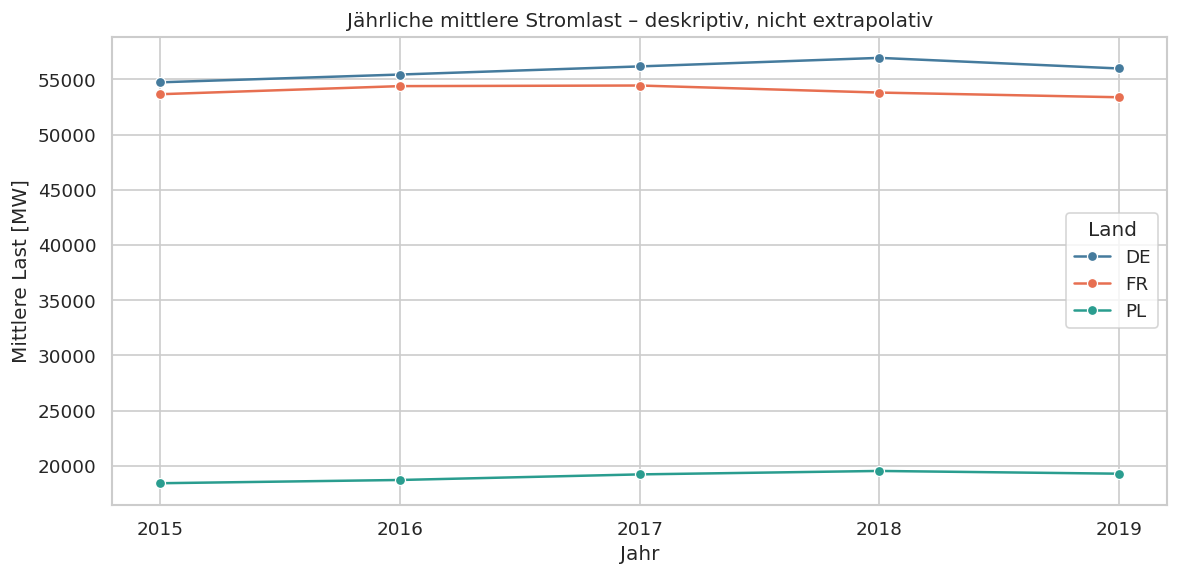

In [17]:
annual_profile = (
    model_data.assign(year=model_data["utc_timestamp"].dt.year)
    .groupby(["country", "year"], observed=True)["load_mw"]
    .mean()
    .reset_index()
)
display(annual_profile.pivot(index="year", columns="country", values="load_mw").round(1))

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=annual_profile,
    x="year",
    y="load_mw",
    hue="country",
    marker="o",
    palette=colors,
)
plt.title("Jährliche mittlere Stromlast – deskriptiv, nicht extrapolativ")
plt.xlabel("Jahr")
plt.ylabel("Mittlere Last [MW]")
plt.xticks(sorted(annual_profile["year"].unique()))
plt.legend(title="Land")
plt.tight_layout()
plt.show()

## 12. Klimatologisches Standardprofil für die spätere App

Für Zukunftsszenarien wird ein typisches Wetterprofil aus der gesamten
Wetterhistorie 1980–2019 gebildet: Median je Land × lokaler Monat ×
lokale Stunde. Dieses Profil dient **nur** der Szenarioebene. Im
historischen Backtest wird das tatsächlich beobachtete Reanalysewetter
der jeweiligen Teststunde verwendet.

,country,local_month,local_hour,temperature_c_median,radiation_direct_wm2_median,radiation_diffuse_wm2_median,climatology_start_utc,climatology_end_utc
0,DE,1,0,-0.9230,0.0000,0.0000,1980-01-01 00:00:00+00:00,2019-12-31 23:00:00+00:00
1,DE,1,1,-0.9685,0.0000,0.0000,1980-01-01 00:00:00+00:00,2019-12-31 23:00:00+00:00
2,DE,1,2,-1.0230,0.0000,0.0000,1980-01-01 00:00:00+00:00,2019-12-31 23:00:00+00:00
3,DE,1,3,-0.9905,0.0000,0.0000,1980-01-01 00:00:00+00:00,2019-12-31 23:00:00+00:00
4,DE,1,4,-1.0620,0.0000,0.0000,1980-01-01 00:00:00+00:00,2019-12-31 23:00:00+00:00
5,DE,1,5,-1.1250,0.0000,0.0000,1980-01-01 00:00:00+00:00,2019-12-31 23:00:00+00:00
6,DE,1,6,-1.1730,0.0000,0.0000,1980-01-01 00:00:00+00:00,2019-12-31 23:00:00+00:00
7,DE,1,7,-1.2295,0.0004,0.0102,1980-01-01 00:00:00+00:00,2019-12-31 23:00:00+00:00


Zeilen im Standardprofil: 864
Historie: 1980-01-01 00:00:00+00:00 bis 2019-12-31 23:00:00+00:00


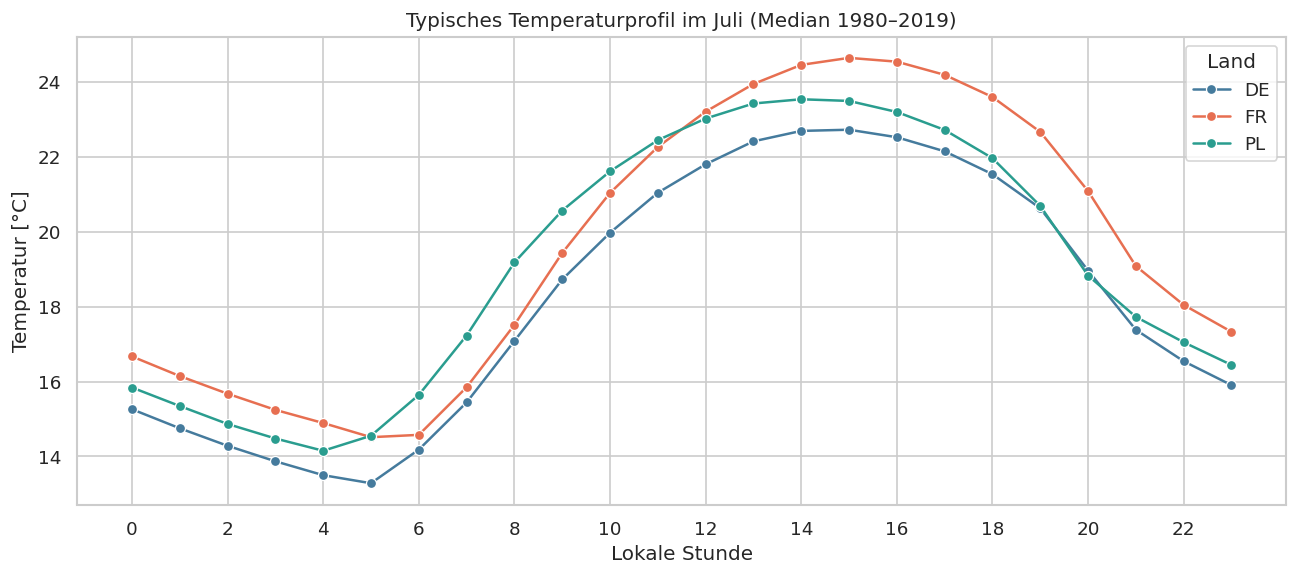

In [18]:
climatology = build_climatology(weather_raw, SPECS)
print("Zeilen im Standardprofil:", len(climatology))
print(
    "Historie:",
    climatology["climatology_start_utc"].min(),
    "bis",
    climatology["climatology_end_utc"].max(),
)
display(climatology.head(8))

plt.figure(figsize=(11, 5))
july = climatology.loc[climatology["local_month"].eq(7)]
sns.lineplot(
    data=july,
    x="local_hour",
    y="temperature_c_median",
    hue="country",
    marker="o",
    palette=colors,
)
plt.title("Typisches Temperaturprofil im Juli (Median 1980–2019)")
plt.xlabel("Lokale Stunde")
plt.ylabel("Temperatur [°C]")
plt.xticks(range(0, 24, 2))
plt.legend(title="Land")
plt.tight_layout()
plt.show()

## 13. Lokale Analyseartefakte speichern

Die bereinigte Modelldatentabelle und das klimatologische Profil werden
komprimiert unter `data/processed/` gespeichert. Dieser Ordner ist in
`.gitignore` ausgeschlossen; die Artefakte sind jederzeit aus Rohdaten
und Code reproduzierbar.

In [19]:
processed_dir = PROJECT_ROOT / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

model_output = processed_dir / "opsd_model_data_2015_2019.csv.gz"
climatology_output = processed_dir / "opsd_weather_climatology_1980_2019.csv.gz"

model_data.to_csv(model_output, index=False, compression="gzip")
climatology.to_csv(climatology_output, index=False, compression="gzip")

print(f"Gespeichert: {model_output.relative_to(PROJECT_ROOT)}")
print(f"Gespeichert: {climatology_output.relative_to(PROJECT_ROOT)}")
print(f"Modelldaten: {model_output.stat().st_size / 1024**2:.1f} MB")
print(f"Klimaprofil: {climatology_output.stat().st_size / 1024**2:.3f} MB")

Gespeichert: data/processed/opsd_model_data_2015_2019.csv.gz
Gespeichert: data/processed/opsd_weather_climatology_1980_2019.csv.gz
Modelldaten: 3.9 MB
Klimaprofil: 0.011 MB


## 14. Fazit der Datenphase

**Gemessene Ergebnisse**

- Lastdatei: 50.401 Datenzeilen, 300 Rohspalten, lückenlose UTC-Achse
  vom 31.12.2014 bis 30.09.2020.
- Wetterdatei: 350.640 Datenzeilen, 85 Rohspalten, lückenlose UTC-Achse
  von 01.01.1980 bis 31.12.2019.
- Gemeinsames Modellfenster: 2015–2019.
- 131.472 mögliche Länder-Stunden vor Zielbereinigung.
- 31 fehlende Lastwerte; 131.441 nutzbare Länder-Stunden.
- Wetterfeatures im gemeinsamen Fenster vollständig.
- Keine doppelten Länder-Zeit-Schlüssel.

**Begründete Entscheidungen**

- Kernländer: DE, FR, PL.
- Fehlende Zielwerte entfernen, nicht imputieren.
- Plausible statistische Extremwerte nicht pauschal löschen.
- Lokale Kalenderfeatures aus UTC plus IANA-Zeitzone ableiten.
- Chronologischer Split: 2015–2017 / 2018 / 2019.
- Historischer Trend bleibt explorativ.
- Typisches Wetterprofil: Median 1980–2019 je Land × Monat × Stunde.

**Nächster Schritt**

Leakage-freie Baselines und mindestens zwei Regressionsmodelle
entwickeln, auf 2018 auswählen und einmalig auf 2019 testen.